# 04 — Full Backtest: Co-Located BESS at Real ERCOT Sites

**Core Question:** If we co-located a 100MW/400MWh battery at an existing ERCOT solar or wind site, what would perfect-foresight arbitrage revenue be — at the node vs. the hub?

**Why this matters:**
- Most BESS revenue analyses use **hub prices**, overstating revenue by ignoring nodal congestion
- $/kW/yr is Modo's BESS Index metric — we compute it directly
- Comparing BESS arbitrage to solar/wind generation revenue shows co-location value

**Sites:** 6 real ERCOT assets with resource node pricing (all HB_WEST)

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = os.path.join(os.pardir, 'data')
PRICES_DIR = os.path.join(DATA_DIR, 'prices')
GEN_DIR = os.path.join(DATA_DIR, 'generation')
REV_DIR = os.path.join(DATA_DIR, 'revenue')
RESULTS_DIR = os.path.join(DATA_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

In [2]:
# BESS Configuration
POWER_MW = 100
ENERGY_MWH = 400
RTE = 0.87
SOC_MIN = 0.05
SOC_MAX = 0.95
SOC_INIT = 0.50
DT = 1.0

# Sites
SITES = {
    'lamesa_solar':           {'type': 'solar', 'mw': 102.0,  'node': 'LAMESASLR_G',   'hub': 'HB_WEST', 'label': 'Lamesa Solar'},
    'misae_solar':            {'type': 'solar', 'mw': 240.0,  'node': 'MISAE_GEN_RN',  'hub': 'HB_WEST', 'label': 'Misae Solar'},
    'longhorn_wind':          {'type': 'wind',  'mw': 200.0,  'node': 'LHORN_N_U1_2',  'hub': 'HB_WEST', 'label': 'Longhorn Wind'},
    'panther_creek_wind_i':   {'type': 'wind',  'mw': 142.5,  'node': 'PC_NORTH_1',    'hub': 'HB_WEST', 'label': 'Panther Creek'},
    'spinning_spur_wind_iii': {'type': 'wind',  'mw': 194.0,  'node': 'SSPURT_WIND1',  'hub': 'HB_WEST', 'label': 'Spinning Spur III'},
    'stanton_wind_energy':    {'type': 'wind',  'mw': 120.0,  'node': 'SWEC_G1',       'hub': 'HB_WEST', 'label': 'Stanton Wind'},
}

HUBS = ['HB_HOUSTON', 'HB_NORTH', 'HB_SOUTH', 'HB_WEST']

print(f'BESS: {POWER_MW} MW / {ENERGY_MWH} MWh, RTE={RTE:.0%}')
print(f'Sites: {len(SITES)}, Hubs: {len(HUBS)}')

BESS: 100 MW / 400 MWh, RTE=87%
Sites: 6, Hubs: 4


## Dispatch Optimizer (from NB 03)

In [3]:
def optimize_dispatch(prices, dt=1.0, power_mw=100, energy_mwh=400,
                      rte=0.87, soc_min=0.05, soc_max=0.95,
                      soc_init=0.50, soc_final=0.50):
    prices = np.asarray(prices, dtype=float)
    T = len(prices)
    eta_ch = np.sqrt(rte)
    eta_dis = np.sqrt(rte)
    soc_min_mwh = soc_min * energy_mwh
    soc_max_mwh = soc_max * energy_mwh
    soc_init_mwh = soc_init * energy_mwh
    soc_final_mwh = soc_final * energy_mwh
    
    p_ch = cp.Variable(T, nonneg=True)
    p_dis = cp.Variable(T, nonneg=True)
    soc = cp.Variable(T + 1, nonneg=True)
    
    revenue = prices @ (p_dis - p_ch) * dt
    objective = cp.Maximize(revenue)
    
    constraints = [
        p_ch <= power_mw,
        p_dis <= power_mw,
        soc[1:] == soc[:-1] + eta_ch * p_ch * dt - (1.0 / eta_dis) * p_dis * dt,
        soc >= soc_min_mwh,
        soc <= soc_max_mwh,
        soc[0] == soc_init_mwh,
        soc[T] == soc_final_mwh,
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return {'status': prob.status, 'revenue': 0, 'p_discharge': np.zeros(T)}
    
    return {
        'p_charge': p_ch.value,
        'p_discharge': p_dis.value,
        'soc': soc.value,
        'revenue': prob.value,
        'status': prob.status,
    }

print('optimize_dispatch() ready')

optimize_dispatch() ready


## Monthly Rolling Backtest

Run the optimizer month-by-month (not all-at-once) for:
- Monthly revenue granularity
- More realistic cyclic SOC constraint per month
- Avoids any single-LP memory concerns

In [4]:
def backtest_year(prices_series, year='2024', **bess_kwargs):
    """Run optimizer month-by-month for a given year, return monthly results."""
    year_prices = prices_series[year].dropna()
    if len(year_prices) < 100:
        return pd.DataFrame()
    
    monthly_results = []
    for month_label, month_data in year_prices.groupby(pd.Grouper(freq='ME')):
        if len(month_data) < 24:
            continue
        result = optimize_dispatch(month_data.values, **bess_kwargs)
        if result['revenue'] == 0 and result.get('status') != 'optimal':
            continue
        monthly_results.append({
            'month': month_label,
            'revenue_usd': result['revenue'],
            'hours': len(month_data),
            'cycles': result['p_discharge'].sum() * DT / ENERGY_MWH,
            'avg_spread': month_data.max() - month_data.min(),
        })
    
    return pd.DataFrame(monthly_results)

print('backtest_year() ready')

backtest_year() ready


## Run Backtest: 4 Hubs + 6 Nodes

In [5]:
# Determine best year to use
sample = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_WEST_rt_hourly.parquet'))['price']
# Check how much 2024 and 2025 data we have
for yr in ['2024', '2025']:
    count = len(sample[yr].dropna())
    print(f'{yr}: {count} hours ({count/8760*100:.0f}% of year)')

BACKTEST_YEAR = '2024'  # Use 2024 for complete year
print(f'\nUsing {BACKTEST_YEAR} for backtest')

2024: 8784 hours (100% of year)
2025: 6791 hours (78% of year)

Using 2024 for backtest


In [6]:
# Run backtest for all 4 hubs
hub_results = {}
for hub in HUBS:
    print(f'  Running {hub}...', end=' ')
    prices = pd.read_parquet(os.path.join(PRICES_DIR, f'{hub}_rt_hourly.parquet'))['price']
    monthly = backtest_year(prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    hub_results[hub] = monthly
    total_rev = monthly['revenue_usd'].sum()
    rev_per_kw = total_rev / (POWER_MW * 1000)
    print(f'${total_rev:,.0f} total, ${rev_per_kw:.1f}/kW/yr, {monthly["cycles"].sum():.0f} cycles')

print('\nHub backtests complete!')

  Running HB_HOUSTON... 

$7,560,744 total, $75.6/kW/yr, 520 cycles
  Running HB_NORTH... 

$7,885,057 total, $78.9/kW/yr, 540 cycles
  Running HB_SOUTH... 

$7,917,991 total, $79.2/kW/yr, 518 cycles
  Running HB_WEST... 

$9,440,895 total, $94.4/kW/yr, 609 cycles

Hub backtests complete!


In [7]:
# Run backtest for all 6 resource nodes
node_results = {}
for slug, info in SITES.items():
    node = info['node']
    label = info['label']
    print(f'  Running {label} ({node})...', end=' ')
    path = os.path.join(PRICES_DIR, f'{node}_rt_hourly.parquet')
    if not os.path.exists(path):
        print('MISSING')
        continue
    prices = pd.read_parquet(path)['price']
    monthly = backtest_year(prices, year=BACKTEST_YEAR,
                            power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                            soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)
    node_results[slug] = monthly
    total_rev = monthly['revenue_usd'].sum()
    rev_per_kw = total_rev / (POWER_MW * 1000)
    print(f'${total_rev:,.0f} total, ${rev_per_kw:.1f}/kW/yr, {monthly["cycles"].sum():.0f} cycles')

print('\nNode backtests complete!')

  Running Lamesa Solar (LAMESASLR_G)... 

$13,624,333 total, $136.2/kW/yr, 649 cycles
  Running Misae Solar (MISAE_GEN_RN)... 

$8,954,506 total, $89.5/kW/yr, 724 cycles
  Running Longhorn Wind (LHORN_N_U1_2)... 

$9,155,035 total, $91.6/kW/yr, 741 cycles
  Running Panther Creek (PC_NORTH_1)... 

$12,014,234 total, $120.1/kW/yr, 660 cycles
  Running Spinning Spur III (SSPURT_WIND1)... MISSING
  Running Stanton Wind (SWEC_G1)... 

$13,276,914 total, $132.8/kW/yr, 618 cycles

Node backtests complete!


## Hub Revenue Summary

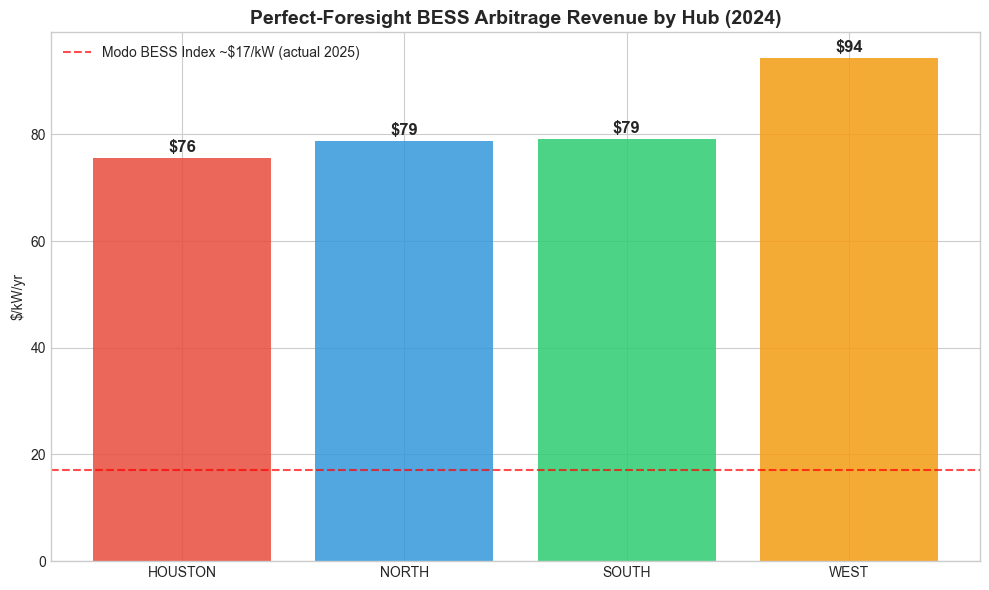

,Location,Type,Annual Revenue ($),$/kW/yr,Total Cycles,Best Month
0,HOUSTON,Hub,7.560744e+06,75.607442,519.704562,May
1,NORTH,Hub,7.885057e+06,78.850570,539.905139,May
2,SOUTH,Hub,7.917991e+06,79.179906,518.228046,May
3,WEST,Hub,9.440895e+06,94.408952,609.307227,May


In [8]:
# Compute annual metrics per hub
hub_summary = []
for hub, monthly in hub_results.items():
    total_rev = monthly['revenue_usd'].sum()
    hub_summary.append({
        'Location': hub.replace('HB_', ''),
        'Type': 'Hub',
        'Annual Revenue ($)': total_rev,
        '$/kW/yr': total_rev / (POWER_MW * 1000),
        'Total Cycles': monthly['cycles'].sum(),
        'Best Month': monthly.loc[monthly['revenue_usd'].idxmax(), 'month'].strftime('%b') if len(monthly) > 0 else 'N/A',
    })

hub_summary_df = pd.DataFrame(hub_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars = ax.bar(hub_summary_df['Location'], hub_summary_df['$/kW/yr'], color=colors, alpha=0.85)
ax.set_title(f'Perfect-Foresight BESS Arbitrage Revenue by Hub ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('$/kW/yr')
for bar, val in zip(bars, hub_summary_df['$/kW/yr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'${val:.0f}', 
            ha='center', fontsize=12, fontweight='bold')

# Add Modo benchmark line
ax.axhline(y=17, color='red', linestyle='--', alpha=0.7, label='Modo BESS Index ~$17/kW (actual 2025)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hub_revenue_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

hub_summary_df

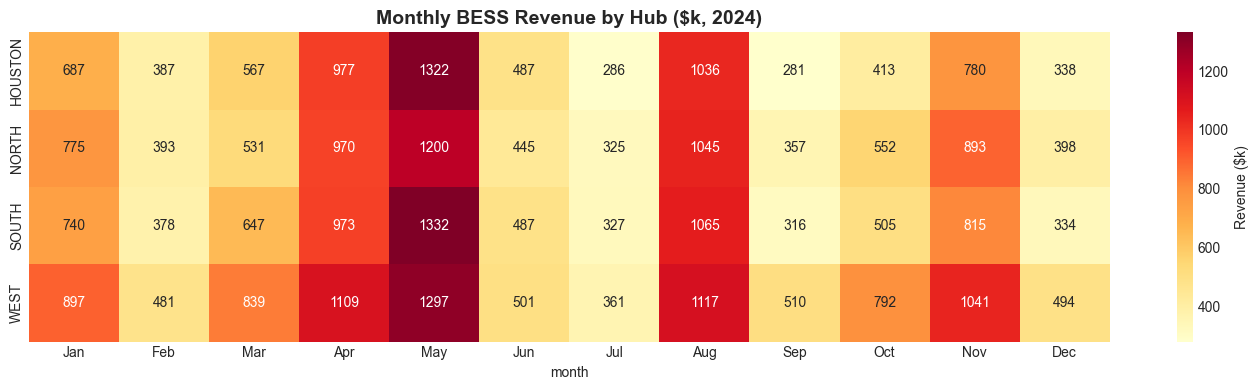

In [9]:
# Monthly revenue heatmap
monthly_rev = pd.DataFrame()
for hub, monthly in hub_results.items():
    m = monthly.set_index('month')['revenue_usd'].copy()
    m.index = m.index.strftime('%b')
    monthly_rev[hub.replace('HB_', '')] = m / 1000  # $k

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(monthly_rev.T, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Revenue ($k)'})
ax.set_title(f'Monthly BESS Revenue by Hub ($k, {BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Node vs Hub: Basis Impact on BESS Revenue

This is the **key differentiator**. For each of the 6 sites, we compare:
- `hub_revenue`: optimizer run on HB_WEST prices
- `node_revenue`: optimizer run on site-specific resource node prices
- `basis_impact = node_revenue - hub_revenue`

In [10]:
# Get HB_WEST as the reference hub for all 6 sites
hub_west_rev = hub_results['HB_WEST']['revenue_usd'].sum()
hub_west_kw = hub_west_rev / (POWER_MW * 1000)

basis_comparison = []
for slug, info in SITES.items():
    if slug not in node_results:
        continue
    node_rev = node_results[slug]['revenue_usd'].sum()
    node_kw = node_rev / (POWER_MW * 1000)
    basis_impact = node_rev - hub_west_rev
    basis_pct = (basis_impact / hub_west_rev) * 100 if hub_west_rev > 0 else 0
    
    basis_comparison.append({
        'Site': info['label'],
        'Type': info['type'].title(),
        'MW': info['mw'],
        'Node': info['node'],
        'Hub Rev ($/kW/yr)': hub_west_kw,
        'Node Rev ($/kW/yr)': node_kw,
        'Basis Impact ($/kW/yr)': (node_kw - hub_west_kw),
        'Basis Impact (%)': basis_pct,
    })

basis_df = pd.DataFrame(basis_comparison)
basis_df.round(1)

,Site,Type,MW,Node,Hub Rev ($/kW/yr),Node Rev ($/kW/yr),Basis Impact ($/kW/yr),Basis Impact (%)
0,Lamesa Solar,Solar,102.0,LAMESASLR_G,94.4,136.2,41.8,44.3
1,Misae Solar,Solar,240.0,MISAE_GEN_RN,94.4,89.5,-4.9,-5.2
2,Longhorn Wind,Wind,200.0,LHORN_N_U1_2,94.4,91.6,-2.9,-3.0
3,Panther Creek,Wind,142.5,PC_NORTH_1,94.4,120.1,25.7,27.3
4,Stanton Wind,Wind,120.0,SWEC_G1,94.4,132.8,38.4,40.6


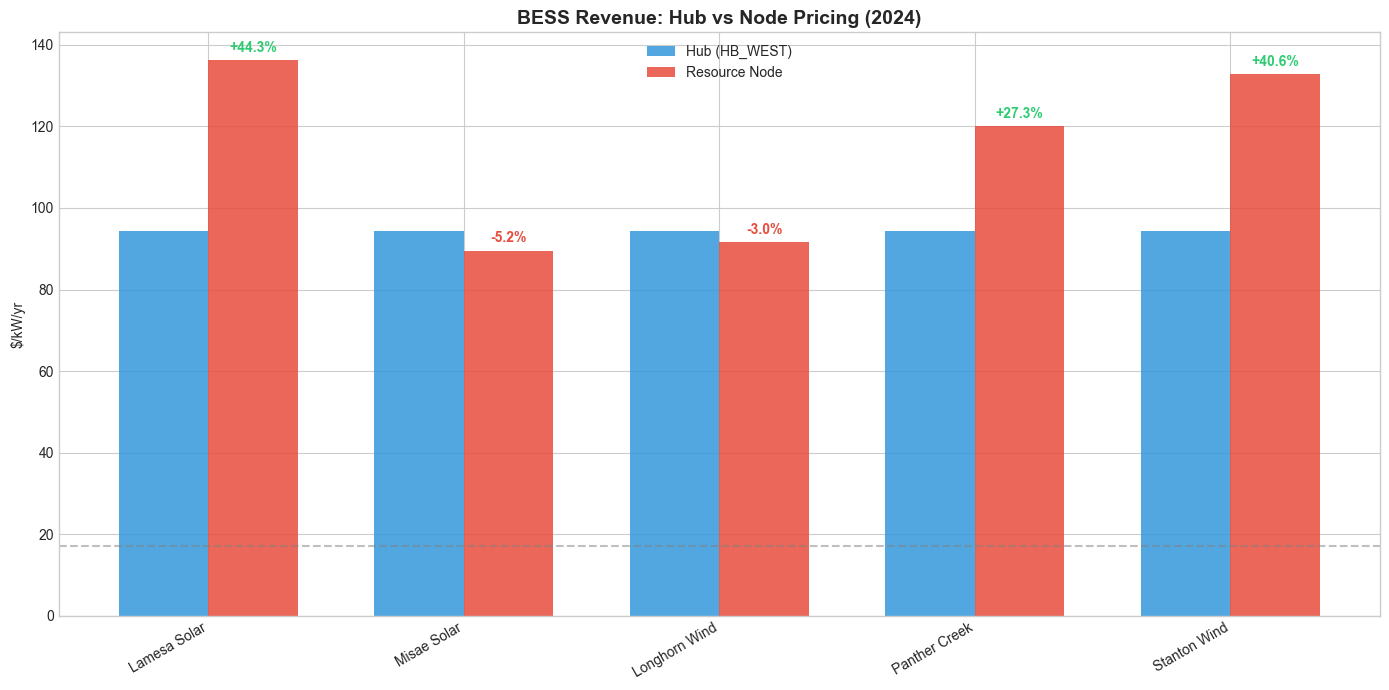

In [11]:
# Grouped bar chart: hub vs node revenue per site
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(basis_df))
width = 0.35

bars1 = ax.bar(x - width/2, basis_df['Hub Rev ($/kW/yr)'], width, 
               label='Hub (HB_WEST)', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, basis_df['Node Rev ($/kW/yr)'], width,
               label='Resource Node', color='#e74c3c', alpha=0.85)

ax.set_xlabel('')
ax.set_ylabel('$/kW/yr')
ax.set_title(f'BESS Revenue: Hub vs Node Pricing ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(basis_df['Site'], rotation=30, ha='right')
ax.legend()

# Add basis impact labels
for i, row in basis_df.iterrows():
    impact = row['Basis Impact (%)']
    color = '#2ecc71' if impact >= 0 else '#e74c3c'
    ax.annotate(f'{impact:+.1f}%', xy=(i + width/2, row['Node Rev ($/kW/yr)'] + 2),
               ha='center', fontsize=10, fontweight='bold', color=color)

ax.axhline(y=17, color='gray', linestyle='--', alpha=0.5, label='Modo actual ~$17/kW')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'hub_vs_node_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

## Co-Location Analysis: BESS + Solar/Wind Revenue

Load historical generation revenue for each site and compare to BESS arbitrage potential.

In [12]:
# Load generation revenue for each site
gen_revenue = {}
for slug, info in SITES.items():
    rev_path = os.path.join(REV_DIR, slug, 'hub', 'rt_historical.parquet')
    if os.path.exists(rev_path):
        rev_df = pd.read_parquet(rev_path)
        # Filter to backtest year using index year
        year_mask = rev_df.index.year == int(BACKTEST_YEAR)
        year_rev = rev_df[year_mask]
        if len(year_rev) > 0:
            total_rev = year_rev['revenue_usd'].sum()
            gen_mw = info['mw']
            gen_revenue[slug] = {
                'total_rev': total_rev,
                'rev_per_kw': total_rev / (gen_mw * 1000),
                'gen_mwh': year_rev['generation_mw'].sum() if 'generation_mw' in year_rev.columns else 0,
            }
            print(f'{info["label"]}: ${total_rev:,.0f} ({total_rev/(gen_mw*1000):.1f} $/kW/yr)')
        else:
            print(f'{info["label"]}: No {BACKTEST_YEAR} data')
    else:
        print(f'{info["label"]}: No revenue file')

Lamesa Solar: $4,431,423 (43.4 $/kW/yr)
Misae Solar: $12,256,067 (51.1 $/kW/yr)
Longhorn Wind: $14,079,701 (70.4 $/kW/yr)
Panther Creek: No revenue file
Spinning Spur III: $15,581,768 (80.3 $/kW/yr)
Stanton Wind: No revenue file


In [13]:
# Build combined comparison table
coloc_rows = []
for slug, info in SITES.items():
    row = {
        'Site': info['label'],
        'Type': info['type'].title(),
        'MW': info['mw'],
    }
    
    # Generation revenue
    if slug in gen_revenue:
        row['Gen Rev ($/kW/yr)'] = gen_revenue[slug]['rev_per_kw']
    else:
        row['Gen Rev ($/kW/yr)'] = np.nan
    
    # BESS revenue at hub
    row['BESS Hub Rev ($/kW/yr)'] = hub_west_kw
    
    # BESS revenue at node
    if slug in node_results:
        row['BESS Node Rev ($/kW/yr)'] = node_results[slug]['revenue_usd'].sum() / (POWER_MW * 1000)
    else:
        row['BESS Node Rev ($/kW/yr)'] = np.nan
    
    coloc_rows.append(row)

coloc_df = pd.DataFrame(coloc_rows)
coloc_df = coloc_df.round(1)
coloc_df

,Site,Type,MW,Gen Rev ($/kW/yr),BESS Hub Rev ($/kW/yr),BESS Node Rev ($/kW/yr)
0,Lamesa Solar,Solar,102.0,43.4,94.4,136.2
1,Misae Solar,Solar,240.0,51.1,94.4,89.5
2,Longhorn Wind,Wind,200.0,70.4,94.4,91.6
3,Panther Creek,Wind,142.5,NaN,94.4,120.1
4,Spinning Spur III,Wind,194.0,80.3,94.4,NaN
5,Stanton Wind,Wind,120.0,NaN,94.4,132.8


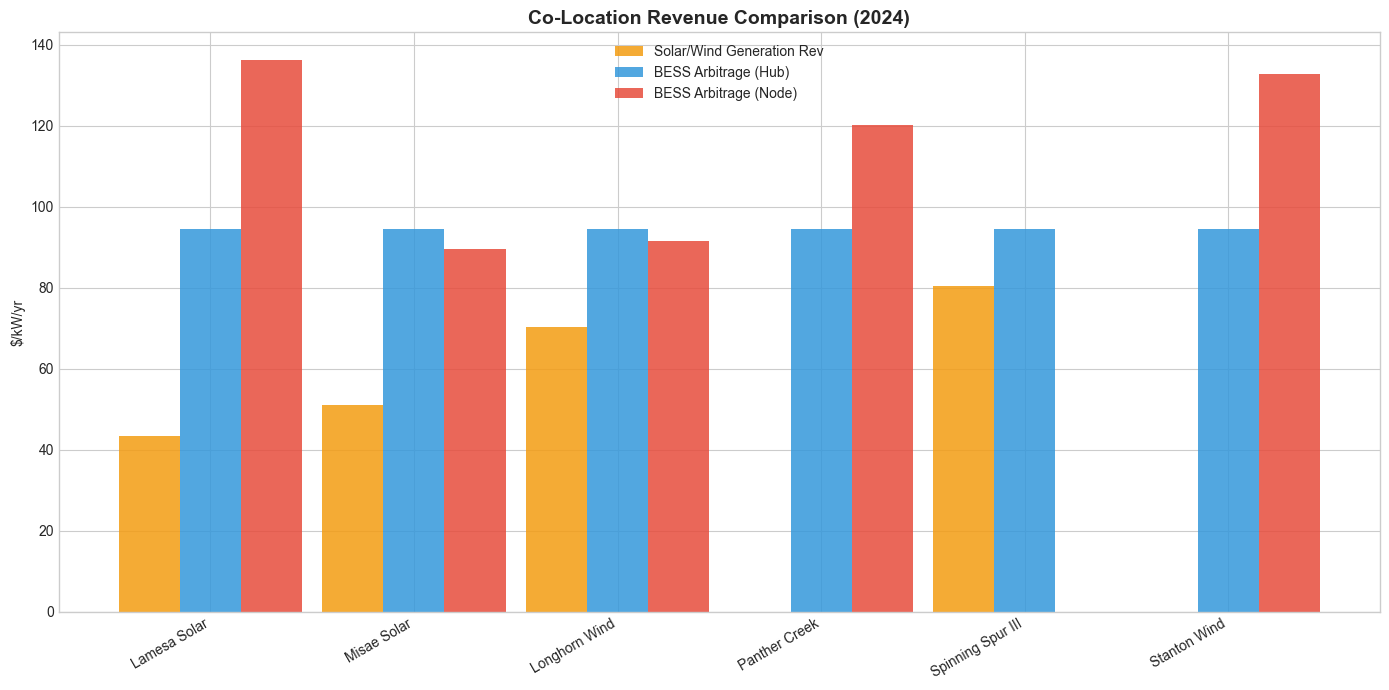

In [14]:
# Grouped bar: generation rev vs BESS rev (node) per site
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(coloc_df))
width = 0.3

if not coloc_df['Gen Rev ($/kW/yr)'].isna().all():
    ax.bar(x - width, coloc_df['Gen Rev ($/kW/yr)'].fillna(0), width,
           label=f'Solar/Wind Generation Rev', color='#f39c12', alpha=0.85)
ax.bar(x, coloc_df['BESS Hub Rev ($/kW/yr)'], width,
       label='BESS Arbitrage (Hub)', color='#3498db', alpha=0.85)
ax.bar(x + width, coloc_df['BESS Node Rev ($/kW/yr)'].fillna(0), width,
       label='BESS Arbitrage (Node)', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(coloc_df['Site'], rotation=30, ha='right')
ax.set_ylabel('$/kW/yr')
ax.set_title(f'Co-Location Revenue Comparison ({BACKTEST_YEAR})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'colocation_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

## Dispatch Profile: 1-Week Zoom

Visualize the optimal dispatch for a volatile summer week at HB_WEST.

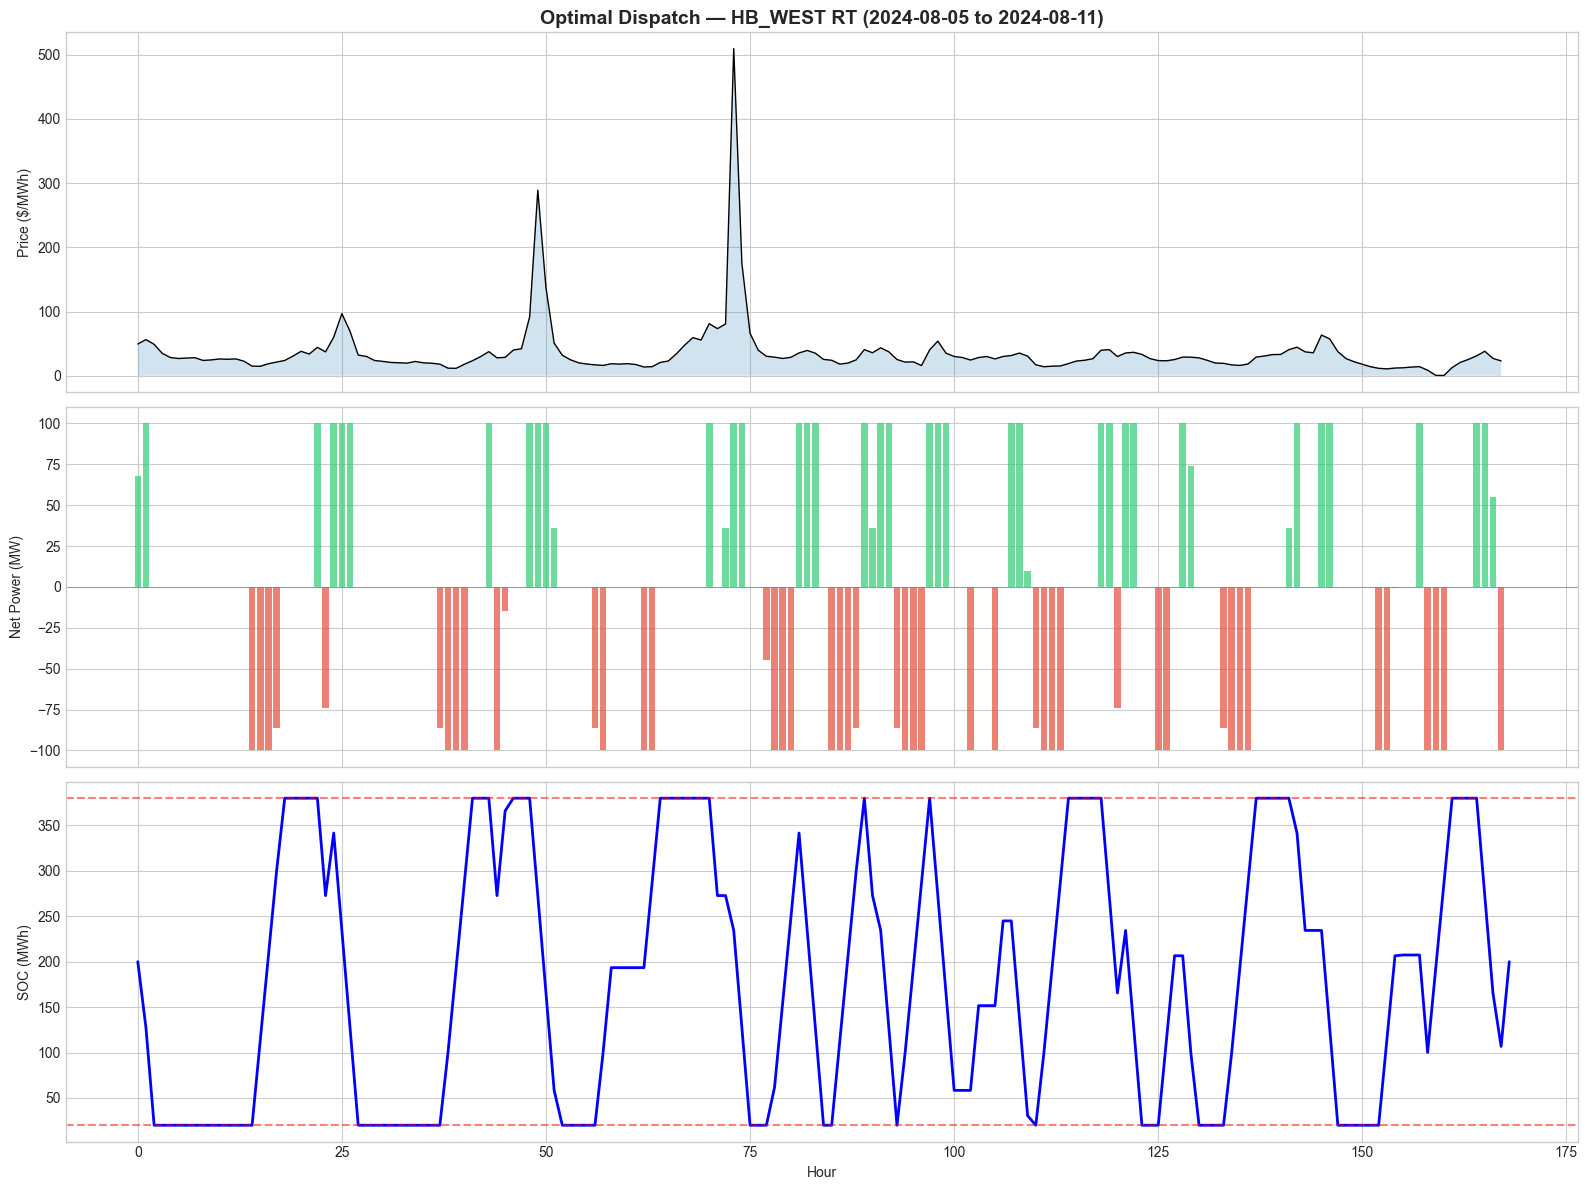

Week revenue: $184,698
Cycles: 9.4


In [15]:
# Pick a volatile summer week
west = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_WEST_rt_hourly.parquet'))
week = west[f'{BACKTEST_YEAR}-08-05':f'{BACKTEST_YEAR}-08-11']['price'].dropna()
if len(week) < 48:
    week = west[f'{BACKTEST_YEAR}-07-15':f'{BACKTEST_YEAR}-07-21']['price'].dropna()

result = optimize_dispatch(week.values, power_mw=POWER_MW, energy_mwh=ENERGY_MWH, rte=RTE,
                           soc_min=SOC_MIN, soc_max=SOC_MAX, soc_init=SOC_INIT, soc_final=SOC_INIT)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
hours = range(len(week))

# Price
axes[0].plot(hours, week.values, 'k-', linewidth=1)
axes[0].fill_between(hours, week.values, alpha=0.2)
axes[0].set_ylabel('Price ($/MWh)')
axes[0].set_title(f'Optimal Dispatch — HB_WEST RT ({week.index[0].date()} to {week.index[-1].date()})',
                  fontsize=14, fontweight='bold')

# Power
net = result['p_discharge'] - result['p_charge']
axes[1].bar(hours, net, color=['#2ecc71' if x > 0 else '#e74c3c' for x in net], alpha=0.7)
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].set_ylabel('Net Power (MW)')
axes[1].set_ylim(-POWER_MW * 1.1, POWER_MW * 1.1)

# SOC
axes[2].plot(range(len(result['soc'])), result['soc'], 'b-', linewidth=2)
axes[2].axhline(y=SOC_MIN * ENERGY_MWH, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(y=SOC_MAX * ENERGY_MWH, color='red', linestyle='--', alpha=0.5)
axes[2].set_ylabel('SOC (MWh)')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dispatch_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Week revenue: ${result["revenue"]:,.0f}')
print(f'Cycles: {result["p_discharge"].sum() * DT / ENERGY_MWH:.1f}')

## Save Results

In [16]:
# Combine all results into a master summary
all_results = []

# Hub results
for hub, monthly in hub_results.items():
    total = monthly['revenue_usd'].sum()
    all_results.append({
        'location': hub,
        'location_type': 'hub',
        'annual_revenue_usd': total,
        'revenue_per_kw_yr': total / (POWER_MW * 1000),
        'total_cycles': monthly['cycles'].sum(),
        'months': len(monthly),
    })

# Node results
for slug, monthly in node_results.items():
    total = monthly['revenue_usd'].sum()
    info = SITES[slug]
    all_results.append({
        'location': info['node'],
        'location_type': 'node',
        'site': info['label'],
        'site_type': info['type'],
        'site_mw': info['mw'],
        'annual_revenue_usd': total,
        'revenue_per_kw_yr': total / (POWER_MW * 1000),
        'total_cycles': monthly['cycles'].sum(),
        'months': len(monthly),
    })

summary_df = pd.DataFrame(all_results)
summary_df.to_parquet(os.path.join(RESULTS_DIR, f'bess_backtest_summary_{BACKTEST_YEAR}.parquet'))
summary_df.to_csv(os.path.join(RESULTS_DIR, f'bess_backtest_summary_{BACKTEST_YEAR}.csv'), index=False)
print(f'Saved {len(summary_df)} results to data/results/')
summary_df.round(1)

Saved 9 results to data/results/


,location,location_type,annual_revenue_usd,revenue_per_kw_yr,total_cycles,months,site,site_type,site_mw
0,HB_HOUSTON,hub,7560744.2,75.6,519.7,12,NaN,NaN,NaN
1,HB_NORTH,hub,7885057.0,78.9,539.9,12,NaN,NaN,NaN
2,HB_SOUTH,hub,7917990.6,79.2,518.2,12,NaN,NaN,NaN
3,HB_WEST,hub,9440895.2,94.4,609.3,12,NaN,NaN,NaN
4,LAMESASLR_G,node,13624333.2,136.2,649.3,12,Lamesa Solar,solar,102.0
5,MISAE_GEN_RN,node,8954506.0,89.5,723.6,12,Misae Solar,solar,240.0
6,LHORN_N_U1_2,node,9155034.6,91.6,741.3,12,Longhorn Wind,wind,200.0
7,PC_NORTH_1,node,12014233.6,120.1,660.3,12,Panther Creek,wind,142.5
8,SWEC_G1,node,13276914.4,132.8,617.6,12,Stanton Wind,wind,120.0


## Key Findings

In [17]:
print('=' * 70)
print('KEY FINDINGS: BESS Energy Arbitrage at ERCOT Sites')
print(f'Backtest Year: {BACKTEST_YEAR}')
print(f'Asset: {POWER_MW} MW / {ENERGY_MWH} MWh, RTE={RTE:.0%}')
print('=' * 70)

# 1. Hub revenue range
hub_vals = hub_summary_df['$/kW/yr']
print(f'\n1. PERFECT-FORESIGHT ARBITRAGE REVENUE BY HUB:')
for _, row in hub_summary_df.iterrows():
    print(f'   {row["Location"]:>10}: ${row["$/kW/yr"]:.0f}/kW/yr')
print(f'   Range: ${hub_vals.min():.0f} – ${hub_vals.max():.0f}/kW/yr')

# 2. Modo comparison
modo_actual = 17
best_hub = hub_vals.max()
print(f'\n2. CAPTURE RATE GAP:')
print(f'   Perfect foresight (best hub): ${best_hub:.0f}/kW/yr')
print(f'   Modo BESS Index (actual 2025): ~${modo_actual}/kW/yr')
print(f'   Implied capture rate: {modo_actual/best_hub*100:.0f}% of theoretical maximum')

# 3. Basis impact
if len(basis_df) > 0:
    avg_basis = basis_df['Basis Impact (%)'].mean()
    worst_site = basis_df.loc[basis_df['Basis Impact (%)'].idxmin()]
    print(f'\n3. NODAL BASIS IMPACT:')
    print(f'   Average basis impact: {avg_basis:+.1f}% vs hub')
    print(f'   Worst site: {worst_site["Site"]} ({worst_site["Basis Impact (%)"]:.1f}%)')
    print(f'   Hub-only analysis overstates revenue by ~{abs(avg_basis):.0f}% at West TX nodes')

# 4. Seasonality
if 'HB_WEST' in hub_results:
    west_monthly = hub_results['HB_WEST'].sort_values('revenue_usd', ascending=False)
    top3_rev = west_monthly.head(3)['revenue_usd'].sum()
    total_rev = west_monthly['revenue_usd'].sum()
    print(f'\n4. REVENUE CONCENTRATION:')
    top3_months = ', '.join(west_monthly.head(3)['month'].dt.strftime('%b').tolist())
    print(f'   Top 3 months ({top3_months}): {top3_rev/total_rev*100:.0f}% of annual revenue')

print(f'\n5. LIMITATIONS:')
print(f'   - Perfect foresight = theoretical upper bound')
print(f'   - No ancillary services, degradation, or transaction costs')
print(f'   - Single-year analysis ({BACKTEST_YEAR})')

KEY FINDINGS: BESS Energy Arbitrage at ERCOT Sites
Backtest Year: 2024
Asset: 100 MW / 400 MWh, RTE=87%

1. PERFECT-FORESIGHT ARBITRAGE REVENUE BY HUB:
      HOUSTON: $76/kW/yr
        NORTH: $79/kW/yr
        SOUTH: $79/kW/yr
         WEST: $94/kW/yr
   Range: $76 – $94/kW/yr

2. CAPTURE RATE GAP:
   Perfect foresight (best hub): $94/kW/yr
   Modo BESS Index (actual 2025): ~$17/kW/yr
   Implied capture rate: 18% of theoretical maximum

3. NODAL BASIS IMPACT:
   Average basis impact: +20.8% vs hub
   Worst site: Misae Solar (-5.2%)
   Hub-only analysis overstates revenue by ~21% at West TX nodes

4. REVENUE CONCENTRATION:
   Top 3 months (May, Aug, Apr): 37% of annual revenue

5. LIMITATIONS:
   - Perfect foresight = theoretical upper bound
   - No ancillary services, degradation, or transaction costs
   - Single-year analysis (2024)
